# Millennial Soil Carbon Model Tutorial

---
## Background
Soils store more carbon than vegetation and the atmosphere combined, so even modest changes in soil carbon cycling can matter for climate. Process-based models help us translate environmental drivers into hypotheses about carbon persistence, turnover, and CO2 release.

**How does soil carbon move?**
- Plant inputs (litter, roots) enter the soil and are transformed by microbes.
- Carbon moves among pools: fresh plant material (POM), dissolved/low-molecular-weight carbon (LMWC), aggregates (AGG), microbial biomass (MIC), and mineral-associated organic matter (MAOM).
- Microbial activity drives decomposition, releasing CO2 and forming new organic matter.
- Soil moisture and temperature regulate microbial processes: warm, moist soils speed up decomposition, while dry or cold soils slow it down.
- Some carbon is stabilized (e.g., in MAOM), while some is lost as CO2.

**What to expect in scenarios:**
- **Warming** generally increases decomposition and CO2 loss, but may also speed up cycling between pools.
- **Drying** can limit microbial activity, reducing both decomposition and stabilization.
- **Increased plant input** can build up soil carbon, but the fate depends on how much is respired vs. stabilized.
- **Microbial efficiency and turnover** (CUE, bd_mult) affect how much carbon is respired vs. retained in soil pools.

When interpreting scenario results, consider:
- Which pools increase or decrease, and why?
- How do CO2 losses compare to changes in total soil carbon?
- Are effects additive, or do they interact (e.g., warming + drying)?

---

## What Millennial Represents
Millennial is a process-based soil carbon model that tracks carbon movement among five pools: particulate organic matter (POM), low-molecular-weight carbon (LMWC), aggregate carbon (AGG), microbial biomass (MIC), and mineral-associated organic matter (MAOM). In this notebook, temperature, soil moisture, and plant carbon inputs drive transfers among these pools and cumulative CO2 loss.

![Millennial model](millennial.png)

## Purpose
Build intuition for how a soil C model works, what information it needs, and how to ask scenario questions with it.

## Learning Goals (1.5 h)
- Identify model inputs, state variables, and outputs
- Run and interpret a baseline simulation
- Test simple climate scenarios (warming, drying, combined)

## Why These Scenarios?
Warming can accelerate decomposition, drying can constrain microbial activity through soil moisture, and changing plant inputs can alter carbon supply to soil. Combining them shows that soil carbon responses are often not obvious from intuition alone.

## Notebook Roadmap
1. Build forcings
2. Compute soil moisture
3. Run Millennial
4. Compare scenarios

## Key References
- Abramoff et al. (2018), *The Millennial model: in search of measurable pools and transformations for modeling soil carbon in the new century*. Biogeochemistry. https://doi.org/10.1007/s10533-017-0409-7
- Abramoff et al. (2022), *Improved global-scale predictions of soil carbon stocks with Millennial Version 2*. Soil Biology and Biochemistry. https://doi.org/10.1016/j.soilbio.2021.108466

**Run order:** execute cells top to bottom.


## What this notebook does

This notebook is a simplified demonstration rather than a full site-calibration exercise. We will:
- Generate one year of daily forcings
- Estimate soil moisture with a simple water balance
- Initialize the model near steady state
- Run a 100-year baseline simulation
- Compare simple climate-change scenarios against the baseline

Focus on interpretation: what changed, why it changed, and which model inputs matter most.

### 1. Import packages
Load the Python libraries used in the tutorial.

In [1]:
# Import all required libraries for modeling, data handling, and plotting
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import norm
from scipy.integrate import solve_ivp
from scipy.interpolate import pchip_interpolate
from scipy import optimize
import numdifftools as nd
from typing import Dict, Tuple

### 2. Parameter dictionaries
Load kinetic and soil parameters used throughout the notebook.

In [2]:
# Function to load kinetic and soil parameters from file and return as dictionaries
def load_par() -> Tuple[Dict[str, float], Dict[str, float]]:
    """Load kinetic and soil dictionaries from the parameter file.

    The file "soilpara_in_fit.txt" contains two columns: the parameter name and its numeric value.
    The values are returned as two dictionaries for kinetics and soil.
    """
    parameters_file = pd.read_table("soilpara_in_fit.txt", delimiter=' ', header=None)
    parameters_file.columns = ["parameter", "value"]
    parameters = {row[0]: float(row[1]) for row in parameters_file.values}
    
    # Add/override some parameters for clarity
    parameters['pH'] = 7  # pH
    parameters['bulkd'] = 1350  # bulk density in kg soil m-3
    parameters['param_pc'] = 0.86  # slope of mineral C - clay relationship
    parameters['depth'] = 0.3  # core sample depth in meter
    
    kinetic_dict = {
        'param_pb': parameters['param_pb'],
        'param_pa': parameters['param_pa'],
        'param_pi': parameters['param_pi'],
        'alpha_pl': parameters['alpha_pl'],
        'eact_pl': parameters['eact_pl'],
        'kaff_pl': parameters['kaff_pl'],
        'kaff_des': parameters['kaff_des'],
        'rate_pa': parameters['rate_pa'],
        'rate_break': parameters['rate_break'],
        'rate_leach': parameters['rate_leach'],
        'rate_ma': parameters['rate_ma'],
        'rate_bd': parameters['rate_bd'],
        'alpha_lb': parameters['alpha_lb'],
        'eact_lb': parameters['eact_lb'],
        'kaff_lb': parameters['kaff_lb'],
        'cue_t': parameters['cue_t'],
        'tae_ref': parameters['tae_ref'],
        'param_p1': parameters['param_p1'],
        'param_p2': parameters['param_p2'],
        'cue_ref': parameters['cue_ref']
    }
    
    soil_dict = {
        'bulkd': parameters['bulkd'],  # kg soil/ m3
        'sand_pct': 50,
        'silt_pct': 30,
        'clay_pct': 20,
        'param_pc': 0.86,
        'lambda_val': parameters['lambda'],
        'matpot': parameters['matpot'],
        'kamin': parameters['kamin'],
        'depth': parameters['depth'],
        'phitex': 0.6,
        'et_max': 0.005,  # m/d
        'ew': 0.0005,  # m/d
        'zr': parameters['depth'],  # rooting depth
        'rstar': 0.1,
        'kstex': 1,  # m/d
        'm': 0.286,
        'pH': parameters['pH'],
        'swilt': 0.08,
        'coloc_factor': 2.8,
        'rel_opt_theta': 0.65,
        'b': 0.75
    }

    return soil_dict, kinetic_dict


### 3. Create forcing functions
Define helper functions to generate daily soil temperature and plant carbon inputs.

#### 3.1 Build model inputs
Climate forcing and plant carbon inputs are generated at daily time step. Here we prescribe rainfall, seasonal soil temperature, and plant C inputs that enter the soil system.

In [3]:
# Functions to generate daily soil temperature and plant carbon inputs
# Used to build model forcings for the simulation

def generate_daily_soil_temperature(MAT: float, Trange: float, days: int = 365, northern_hemisphere: bool = True) -> np.ndarray:
    '''Create an annual sinusoidal soil temperature cycle.'''
    PIseq = np.linspace(0, np.pi, days)
    coef = 1.5 if northern_hemisphere else -1.5
    soil_temps = (Trange / 2) * np.sin((2 * PIseq) - coef) + MAT
    return soil_temps

def calculate_annual_to_daily_ct(seqDAY: np.ndarray, peakDAY: int, sdNPP: float, annNPP: float) -> np.ndarray:
    '''Distribute annual carbon input using a normal curve.'''
    daily_prob = norm.pdf(seqDAY, peakDAY, sdNPP)
    daily_prob /= daily_prob.sum()
    daily_ct = daily_prob * annNPP
    return daily_ct

def calculate_aboveground_ct(daily_ct: np.ndarray, RtoSi: float, aHARVj: float) -> np.ndarray:
    '''Partition daily input to aboveground material after harvest.'''
    return daily_ct * (1 / (RtoSi + 1)) * (1 - aHARVj)

def calculate_belowground_ct(daily_ct: np.ndarray, RtoSi: float, bHARVj: float, depth: float, Rdep50: float, Rdepmax: float) -> np.ndarray:
    '''Partition daily input to roots and belowground structures.'''
    bCT = daily_ct * (RtoSi / (RtoSi + 1)) * (1 - bHARVj)
    proportion_factor = (depth * (Rdep50 + Rdepmax)) / (Rdepmax * (Rdep50 + depth))
    return bCT * proportion_factor

def add_noise(carbon_input: np.ndarray, noise_level: float = 0.05) -> np.ndarray:
    '''Add Gaussian noise to a time series to mimic natural variability.'''
    noise = np.random.normal(0, noise_level * carbon_input, size=carbon_input.shape)
    return carbon_input + noise

def generate_forcings(generate_plot: bool = False) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    '''Construct daily rainfall, soil temperature, and plant carbon inputs.'''
    daily_mean_rainfall = pd.read_csv('daily_mean_rainfall.csv')
    daily_mean_rainfall = daily_mean_rainfall[daily_mean_rainfall['year'] == 2020].reset_index()
    daily_rainfall = daily_mean_rainfall['secPrecipBulk'].values * 0.001  # m/d

    num_pt = len(daily_rainfall)
    mean_annual_temperature = 10
    temperature_range = 18
    daily_soil_temperatures = generate_daily_soil_temperature(mean_annual_temperature, temperature_range, days=num_pt)

    if generate_plot:
        fig, ax1 = plt.subplots(figsize=(7, 4))
        ax1.plot(daily_soil_temperatures, label='Daily Soil Temperature', color='tab:blue')
        ax1.set_xlabel('Day of the Year')
        ax1.set_ylabel('Soil Temperature (°C)', color='tab:blue')
        ax1.tick_params(axis='y', labelcolor='tab:blue')
        ax2 = ax1.twinx()
        ax2.bar(range(len(daily_rainfall)), daily_rainfall, label='Daily Rainfall', color='tab:gray', alpha=0.5)
        ax2.set_ylabel('Rainfall (m/day)', color='tab:gray')
        ax2.tick_params(axis='y', labelcolor='tab:gray')
        fig.tight_layout()
        ax1.legend(loc='upper left')
        ax2.legend(loc='upper right')
        plt.grid(True)
        plt.show()

    annNPP = 450
    peakNPP_DAY = 182
    peakLitter_DAY = 200
    sdNPP = 30
    RtoSi = 0.5
    aHARV = 0.1
    bHARV = 0.1
    depth = 15
    Rdep50 = 30
    Rdepmax = 100

    seqDAY = np.arange(1, num_pt + 1)
    daily_ct_npp = calculate_annual_to_daily_ct(seqDAY, peakNPP_DAY, sdNPP, annNPP)
    daily_ct_litter = calculate_annual_to_daily_ct(seqDAY, peakLitter_DAY, sdNPP, annNPP)
    jaCT = calculate_aboveground_ct(daily_ct_litter, RtoSi, aHARV)
    jbCT = calculate_belowground_ct(daily_ct_npp, RtoSi, bHARV, depth, Rdep50, Rdepmax)

    jaCT_noisy = add_noise(jaCT, noise_level=0.05)
    jbCT_noisy = add_noise(jbCT, noise_level=0.05)
    total_plant_input = jaCT_noisy + jbCT_noisy

    if generate_plot:
        plt.figure(figsize=(7, 4))
        plt.plot(seqDAY, total_plant_input, label='Total Plant Carbon Input', linestyle='dashed', color='black')
        plt.xlabel('Day of the Year')
        plt.ylabel(r"Plant carbon Input (gC m$^{-2}$ day$^{-1}$)")
        plt.grid(True)
        plt.tight_layout()

    return daily_rainfall, daily_soil_temperatures, total_plant_input


### Generate example forcings
Create one year of rainfall, soil temperature, and plant C inputs, then plot them.

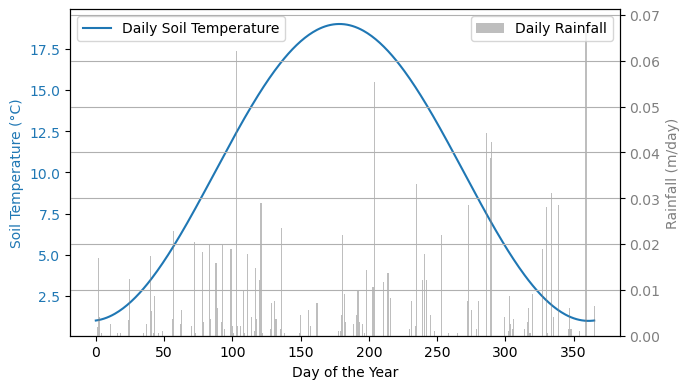

np.float64(328.9443401606537)

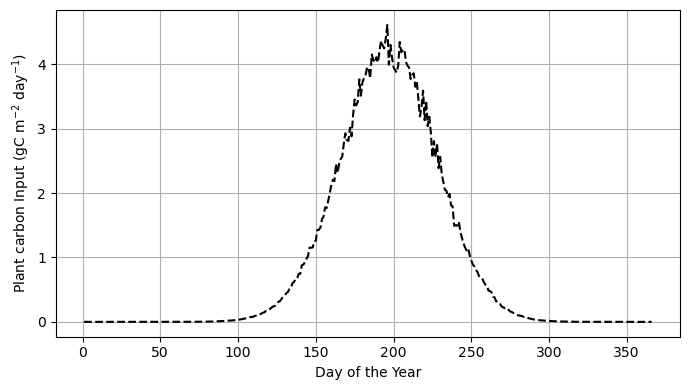

In [4]:
# Generate one year of rainfall, soil temperature, and plant C inputs, then plot them
rainfall, daily_soil_temperatures, total_plant_input = generate_forcings(generate_plot=True)
total_plant_input.sum()

## 4. Soil water balance
Convert rainfall into soil moisture (`theta`). This matters because microbial activity and carbon processing depend strongly on water availability.

### 4.1 Water balance equations
Define a simple bucket-style water balance to convert rainfall into soil moisture.

In [5]:
# Function to compute the soil water balance for one time step
def soil_wat_bal(theta, dt, rain, soil_dict):
    """
    Compute the soil water balance for one time step.

    Parameters
    ----------
    theta : float
        Current volumetric soil moisture (m^3/m^3).
    dt : float
        Time step (days).
    rain : float
        Rainfall rate (m/day).
    soil_dict : dict
        Soil parameters. Required keys: phitex, swilt, et_max, ew, zr, rstar, kstex, m.

    Returns
    -------
    np.ndarray
        [theta, rain, runoff, ET, Kh]
    """
    def evapotranspiration(s, soil_dict):
        if s <= soil_dict['swilt']:
            et = 0
        elif soil_dict['swilt'] < s <= soil_dict['phitex']:
            et = soil_dict['ew'] + (soil_dict['et_max'] - soil_dict['ew']) * (s - soil_dict['swilt']) / \
                (soil_dict['phitex'] - soil_dict['swilt'])
        else:
            et = soil_dict['et_max']
        return et

    # Soil water storage capacity
    swc = soil_dict['zr']  # m

    # Canopy interception
    tf = rain - rain * soil_dict['rstar']  # Througfall   # m/day

    # Add througfall
    theta = theta + tf / swc   # Dimensionless
    # Verify if there is runoff
    if theta > soil_dict['phitex']:
        q = (theta - soil_dict['phitex']) * swc
        theta = soil_dict['phitex']
        Kh = soil_dict['kstex']
    else:
        q = 0
        # Calculate Effective Saturation (Se)
        theta_r = soil_dict['swilt']
        theta_s = soil_dict['phitex']
        Se = (theta - theta_r) / (theta_s - theta_r)
        Se = np.clip(Se, 0, 1)  # Ensure Se is within [0,1]

        # Calculate Hydraulic Conductivity (Kh) using Mualem-van Genuchten
        # Avoid division by zero when Se=0
        m = soil_dict['m']
        if Se > 0:
            Kh = soil_dict['kstex'] * (Se ** 0.5) * (1 - (1 - Se ** (1 / m)) ** m) ** 2  # m/day
        else:
            Kh = 0
    et = evapotranspiration(theta, soil_dict)
    theta = theta - (et + Kh) * dt / swc
    theta = max(theta, soil_dict['swilt'])  # keep theta above wilting point

    return np.array([theta, rain, q, et, Kh])


### Run the water balance
Simulate daily soil moisture and visualize how rainfall events affect `theta`.

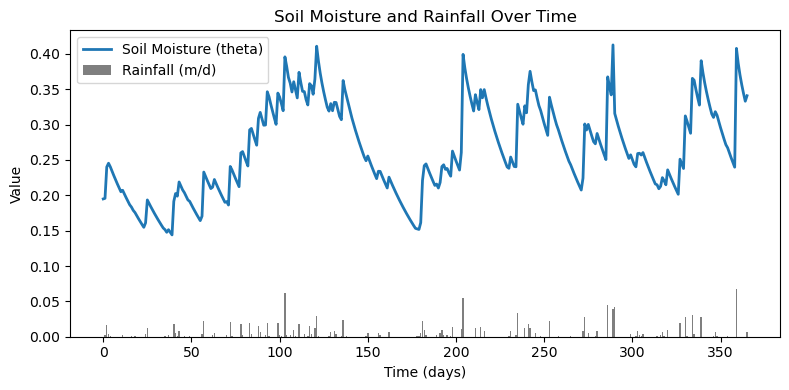

In [6]:
# Run the water balance simulation for the year and plot soil moisture and rainfall
soil_dict, kinetic_dict = load_par()

SWB = np.zeros((len(rainfall), 5))
s=0.2
for i in range(len(rainfall)):
    result = soil_wat_bal(s, 1,  rainfall[i], soil_dict)
    s = result[0]
    SWB[i] = result

SWB_df = pd.DataFrame(SWB)
SWB_df.columns = ['theta', 'Rain (m/d)', 'Runoff (m/d)', 'ET (m/d)', 'Kh (m/d)']
SWB_df['time [day]'] = np.arange(len(rainfall))

plt.figure(figsize=(8, 4))
plt.plot(SWB_df['time [day]'], SWB_df['theta'], label='Soil Moisture (theta)', linewidth=2)
plt.bar(SWB_df['time [day]'], SWB_df['Rain (m/d)'], label='Rainfall (m/d)', color='tab:gray', alpha=1)
plt.xlabel('Time (days)')
plt.ylabel('Value')
plt.title('Soil Moisture and Rainfall Over Time')
plt.legend()
plt.tight_layout()

### 5. Millennial equations
Define process-rate equations, steady-state estimation, dynamic simulation, and plotting utilities.

## 5. Millennial model functions
These functions compute pool changes and fluxes at each time step.

In [7]:
# Millennial model core functions: process rates, steady-state, simulation, and plotting

def Yan2018(theta,phi, clay,coloc_factor, rel_opt_theta,b):
    ktheta = 0.1
    # def compute_a(clay, coloc_factor):
    #     if clay < 0.046 * 100 / coloc_factor:
    #         return 0
    #     elif clay <= 104.6/2.8:
    #         return (coloc_factor * clay / 100) - 0.046
    #     else:
    #         return 1
    def compute_a(clay, coloc_factor):
        if clay <= (1+0.046)*100/coloc_factor:
            return (coloc_factor * clay / 100) - 0.046
        else:
            return 1
    theta_opt =rel_opt_theta*phi 
    ns=2
    
    if theta<theta_opt:
        fm= ((ktheta+theta_opt)/(ktheta+theta))*(theta/theta_opt)**(1+compute_a(clay,coloc_factor)*ns)
    else:
        fm = ((phi - theta)/(phi-theta_opt))**b
    return fm


def cal_derivatives(t, state, npp, st, sw, kinetic_dict, soil_dict, default_moisture=True):
    """
    Compute the derivatives of state variables in the Millennial soil carbon model.
    """
    POM, LMWC, AGG, MIC, MAOM = state

    # Extracting forcing_var data
    temperature = np.interp(t, np.arange(0, len(st)), st)
    plant_input = np.interp(t, np.arange(0, len(npp)), npp)
    theta = np.interp(t, np.arange(0, len(sw)), sw)

    porosity = soil_dict['phitex']

    param_claysilt = soil_dict['silt_pct']+soil_dict['clay_pct']

    # Soil type properties
    kaff_lm = np.exp(-kinetic_dict['param_p1'] * soil_dict['pH'] - kinetic_dict['param_p2']) * kinetic_dict['kaff_des']
    param_qmax = soil_dict['depth'] * soil_dict['bulkd'] * param_claysilt * soil_dict['param_pc']

    if default_moisture:
        scalar_wd = (theta / porosity)**(0.5)
        spot = np.exp(soil_dict['lambda_val'] * -soil_dict['matpot'])
        so2 = (soil_dict['kamin'] + (1 - soil_dict['kamin']) * ((porosity - theta) / porosity)**0.5)
        scalar_wb = spot * so2 * scalar_wd
    else:
        coloc_a = soil_dict['coloc_factor']*soil_dict['clay_pct']/100 - 0.046 if soil_dict['clay_pct'] < 100/soil_dict['coloc_factor'] else 1  # from fig 6 of Yan 2018 Nat Comm
        scalar_wd = (theta / porosity)**(0.5*coloc_a)
        scalar_wb = Yan2018(theta, porosity, soil_dict['clay_pct'], soil_dict['coloc_factor'],
                            soil_dict['rel_opt_theta'],soil_dict['b'])
    

    # Decomposition rates
    gas_const = 8.31446
    vmax_pl = kinetic_dict['alpha_pl'] * np.exp(-kinetic_dict['eact_pl'] / (gas_const * (temperature + 273.15)))
    f_PO_LM = vmax_pl * scalar_wd * POM * MIC / (kinetic_dict['kaff_pl'] + MIC)
    f_PO_AG = kinetic_dict['rate_pa'] * scalar_wd * POM
    f_AG_break = kinetic_dict['rate_break'] * scalar_wd * AGG

    f_LM_leach = kinetic_dict['rate_leach'] * scalar_wd * LMWC

    f_LM_MA = scalar_wd * kaff_lm * LMWC * (1 - MAOM / param_qmax)
    f_MA_LM = kinetic_dict['kaff_des'] * MAOM / param_qmax
    vmax_lb = kinetic_dict['alpha_lb'] * np.exp(-kinetic_dict['eact_lb'] / (gas_const * (temperature + 273.15)))
    f_LM_MB = vmax_lb* scalar_wb * MIC * LMWC / (kinetic_dict['kaff_lb'] + LMWC)
    f_MB_turn = kinetic_dict['rate_bd'] * MIC**2.0
    f_MA_AG = kinetic_dict['rate_ma'] * scalar_wd * MAOM
    f_CO2 = f_LM_MB * (1 - (kinetic_dict['cue_ref'] - kinetic_dict['cue_t'] * (temperature - kinetic_dict['tae_ref'])))

    # mass balance
    dPOM = plant_input * kinetic_dict['param_pi'] + f_AG_break * kinetic_dict['param_pa'] - f_PO_AG - f_PO_LM
    dLMWC = plant_input * (1. - kinetic_dict['param_pi']) - f_LM_leach + f_PO_LM - f_LM_MA - \
        f_LM_MB + f_MB_turn * (1. - kinetic_dict['param_pb']) + f_MA_LM
    dAGG = f_MA_AG + f_PO_AG - f_AG_break
    dMIC = f_LM_MB - f_MB_turn - f_CO2
    dMAOM = f_LM_MA - f_MA_LM + f_MB_turn * kinetic_dict['param_pb'] - f_MA_AG + f_AG_break * (1. - kinetic_dict['param_pa'])
    fluxes = {
        'f_AG_break': f_AG_break,
        'f_POM_to_AGG': f_PO_AG,
        'f_POM_to_DOM': f_PO_LM,
        'f_MAOM_to_DOM': f_MA_LM,
        'f_DOM_to_MAOM': f_LM_MA,
        'f_DOM_leach': f_LM_leach,
        'f_DOM_to_MIC': f_LM_MB,
        'f_MB_turn':f_MB_turn,
        'f_CO2':f_CO2
    }

    return np.array([dPOM, dLMWC, dAGG, dMIC, dMAOM]), fluxes


def cal_steady_state(forcing_var, kinetic_dict, soil_dict, calc_eigen=False,default_moisture=True):
    """
    Calculate the steady state of the Millennial model using Newton-Krylov method.
    """
   
    num_years = 1
    forcing_var_time = np.arange(1, num_years * 365 + 1)
    st = np.interp(forcing_var_time, forcing_var_time, np.tile(np.mean(forcing_var['forc_st']), len(forcing_var_time)))
    sw =  np.interp(forcing_var_time, forcing_var_time, np.tile(np.mean(forcing_var['forc_sw']), len(forcing_var_time)))
    npp = np.interp(forcing_var_time, forcing_var_time, np.tile(np.mean(forcing_var['forc_npp']), len(forcing_var_time)))
    
    t = 10
    def fun(state):
        dCdt, _ = cal_derivatives(t, state,npp, st, sw, kinetic_dict, soil_dict, default_moisture=default_moisture)
        return dCdt
    
    sol = optimize.newton_krylov(fun, np.array([500, 5, 500, 10, 1000]), maxiter=2000)

    # stability analysis
    if calc_eigen:
        jac_fun = nd.Jacobian(fun)
        jac = jac_fun(sol)
        eig, vec = np.linalg.eig(jac)
        return sol, eig
    else:
        return sol

def dynamic_simulation(forcing_var, kinetic_dict, soil_dict,
            state={'POM': 1, 'LMWC': 1, 'AGG': 1, 'MIC': 1, 'MAOM': 1},
            default_moisture=True):
    """
    Run a dynamic simulation of the Millennial model for a given set of forcings and initial state.
    """
    init_Cpool = np.array(list(state.values()))
    
    num_steps = len(forcing_var)

    forcing_var_time = np.arange(0, num_steps, 1)

    st_dt = pchip_interpolate(np.arange(len(forcing_var['forc_st'])), forcing_var['forc_st'], forcing_var_time)

    npp_dt = pchip_interpolate(np.arange(len(forcing_var['forc_npp'])), forcing_var['forc_npp'], forcing_var_time)

    sw_dt = pchip_interpolate(np.arange(len(forcing_var['forc_sw'])), forcing_var['forc_sw'], forcing_var_time)
    
    def maas_bal_fun(t, state,npp_dt, st_dt, sw_dt, kinetic_dict, soil_dict, default_moisture):
        dCdt, _ = cal_derivatives(t, state,npp_dt, st_dt, sw_dt, kinetic_dict, soil_dict, default_moisture)
        return dCdt
        
    t_span = (0, num_steps) # simulation period
    sol = solve_ivp(
                    maas_bal_fun, 
                    t_span, 
                    init_Cpool, 
                    args=(npp_dt, st_dt, sw_dt, kinetic_dict, soil_dict, default_moisture), 
                    t_eval=np.arange(0, num_steps)
                )

    y = np.hstack((sol.t.reshape(-1, 1), sol.y.T))

    millennialC = pd.DataFrame(y, columns=["time [day]","POM [gC m-2]", "LMWC [gC m-2]",
                               "AGG [gC m-2]", "MIC [gC m-2]", "MAOM [gC m-2]"])

    t = millennialC['time [day]']
    fluxes_all = {}

    for i in range(len(t)):
        state = millennialC.loc[i,['POM [gC m-2]', 'LMWC [gC m-2]', 'AGG [gC m-2]','MIC [gC m-2]', 'MAOM [gC m-2]']].values

        # Compute fluxes using the derivative function
        _, fluxes = cal_derivatives(t[i], state,npp_dt, st_dt, sw_dt, kinetic_dict, soil_dict, default_moisture=default_moisture)

        # Store fluxes in a structured format
        for key, value in fluxes.items():
            if key not in fluxes_all:
                fluxes_all[key] = []
            fluxes_all[key].append(value)

    for key in fluxes_all:
        fluxes_all[key] = np.array(fluxes_all[key])
    fluxes_df= pd.DataFrame(fluxes_all)
    millennialC=pd.concat((millennialC,fluxes_df), axis=1)    
    return millennialC, fluxes_df


def plot_pools(millennialC):
    """
    Plot the main C pools, cumulative CO2, and respiration rate from the Millennial model output.
    """
    sns.set_theme(style="whitegrid", font_scale=1.2)
    # plot C pools--------------
    pools = ['POM [gC m-2]', 'LMWC [gC m-2]', 'AGG [gC m-2]',
       'MIC [gC m-2]', 'MAOM [gC m-2]']
    millennialC['time [year]']=millennialC['time [day]']/365
    fig1, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
    
    # 1st column: C pools
    for col in pools:
        axes[0].plot(millennialC['time [year]'], millennialC[col], label=col, linewidth=2)
    axes[0].set_ylabel(r'C stocks')
    axes[0].set_xlabel("Time [years]") 
    axes[0].legend(loc='best')
    # axes[0].grid()

    
    # 2nd column: Cumulative CO2
    millennialC['CO2 [gC m-2]'] = np.cumsum(millennialC['f_CO2'])
    axes[1].plot(millennialC['time [year]'], millennialC['CO2 [gC m-2]'], linewidth=2)
    axes[1].set_ylabel(r"CO$_2$ [gC $m^{-2}$]")
    axes[1].set_xlabel("Time [years]") 
    # axes[1].grid()
    
    # 3rd column: Respiration rate
    def f(x):
        return np.interp(x, millennialC['time [day]'], millennialC['CO2 [gC m-2]'])
    df = nd.Derivative(f, order=2)
    resp = df(millennialC['time [day]'].values)
    axes[2].plot(millennialC['time [year]'], resp, '-', linewidth=2)
    axes[2].set_ylabel(r"Respiration rate [gC m$^{-2}$ d$^{-1}$]")
    axes[2].set_xlabel("Time [years]") 
    # axes[2].grid()
    
    plt.tight_layout()
    # return fig1


## 4) Steady-state initialization
Estimate starting pool sizes before long-term dynamic simulation. This gives a reasonable initial condition so scenario responses are easier to interpret.

### Estimate initial pool sizes
Combine the forcings and solve for approximate steady-state pool sizes.

In [8]:
base_forcings = pd.DataFrame({'forc_st': daily_soil_temperatures,
                            'forc_sw': SWB_df['theta'],
                            'forc_npp': total_plant_input
                            })
sol = cal_steady_state(base_forcings, kinetic_dict, soil_dict)
# nice print of steadty state pools
ss_pools = pd.DataFrame([{
    'POM [gC m-2]': sol[0],
    'LMWC [gC m-2]': sol[1],
    'AGG [gC m-2]': sol[2],
    'MIC [gC m-2]': sol[3],
    'MAOM [gC m-2]': sol[4]
}])
ss_pools

,POM [gC m-2],LMWC [gC m-2],AGG [gC m-2],MIC [gC m-2],MAOM [gC m-2]
0,509.388059,4.445516,1538.152943,8.145563,4498.765375


## 5) Baseline dynamic simulation (100 years)
Run the baseline first; later scenarios are compared against this run. Think of this as the reference climate and input regime.

### Build repeated baseline forcing
Repeat the one-year forcing record to create a 100-year baseline simulation.

In [9]:
forcing_var_repeated = pd.concat([base_forcings] * 10, ignore_index=True)

# --- Step 7: Construct final dictionary ---
repeated_forcing_df = pd.DataFrame({
    'forc_st': forcing_var_repeated['forc_st'].to_numpy(),
    'forc_sw': forcing_var_repeated['forc_sw'].to_numpy(),
    'forc_npp': forcing_var_repeated['forc_npp'].to_numpy(),
})


### Run the baseline model
Simulate carbon pool trajectories under baseline conditions.

In [10]:
output, _ = dynamic_simulation(repeated_forcing_df, kinetic_dict, soil_dict,
                                    state={'POM': sol[0], 'LMWC': sol[1], 'AGG': sol[2],
                                           'MIC': sol[3], 'MAOM': sol[4]}, 
                                    )

### Inspect baseline output
Display the baseline simulation table.

In [11]:
output

,time [day],POM [gC m-2],LMWC [gC m-2],AGG [gC m-2],MIC [gC m-2],MAOM [gC m-2],f_AG_break,f_POM_to_AGG,f_POM_to_DOM,f_MAOM_to_DOM,f_DOM_to_MAOM,f_DOM_leach,f_DOM_to_MIC,f_MB_turn,f_CO2
0,0.0,509.388059,4.445516,1538.152943,8.145563,4498.765375,17.531667,5.225345,0.440410,0.258327,0.653602,0.003800,0.492637,0.298576,0.316406
1,1.0,509.510123,4.177575,1538.153519,8.020993,4498.727189,17.568982,5.237719,0.435256,0.258325,0.615517,0.003579,0.457153,0.289514,0.293683
2,2.0,509.644165,3.945067,1538.155336,7.898604,4498.650135,19.459073,5.802719,0.475585,0.258320,0.643795,0.003743,0.451234,0.280746,0.289962
3,3.0,509.790337,3.745274,1538.158531,7.778437,4498.535870,19.671813,5.867828,0.474467,0.258314,0.617877,0.003592,0.424904,0.272268,0.273132
4,4.0,509.941295,3.589356,1538.162980,7.657524,4498.388866,19.468862,5.808994,0.463374,0.258305,0.586050,0.003407,0.399695,0.263870,0.257024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3655,3655.0,452.774340,1.978299,1358.738459,3.791572,3987.746174,21.346456,6.401979,0.250753,0.228983,0.416774,0.002331,0.114153,0.064692,0.073286
3656,3656.0,453.161241,1.960189,1358.830253,3.767884,3987.234167,20.944933,6.286502,0.244734,0.228954,0.405179,0.002266,0.112631,0.063886,0.072311
3657,3657.0,453.535677,1.948696,1358.921851,3.744471,3986.728926,20.583618,6.182743,0.239305,0.228925,0.395843,0.002214,0.111342,0.063095,0.071490
3658,3658.0,453.899288,1.941984,1359.013425,3.721384,3986.230279,20.249918,6.086975,0.234313,0.228896,0.388073,0.002170,0.110237,0.062319,0.070789


### Plot baseline pools and fluxes
Visualize the main pools, cumulative CO2, and respiration behavior.

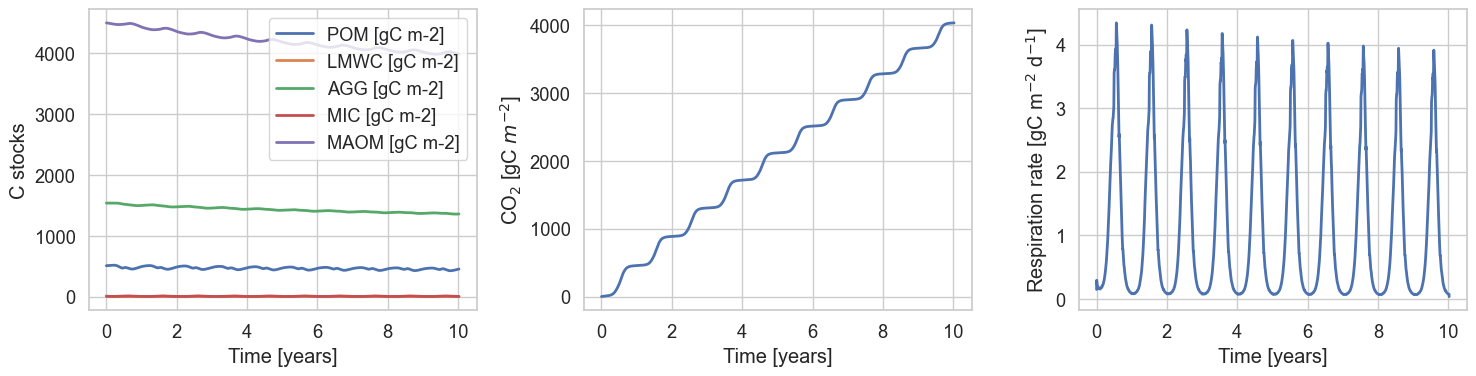

In [12]:
plot_pools(output)

### Reproducibility
Set a random seed so classroom results are consistent across runs.

In [13]:
# Reproducibility for classroom runs
np.random.seed(42)

## 6) Scenario lab (simple climate experiments)

**Inputs:** `forc_st` (temperature), `forc_sw` (soil moisture), `forc_npp` (plant C input)  
**Outputs:** pool trajectories and cumulative CO2

**Scenarios in this notebook:**
- `Baseline`: present-day reference run
- `Warming (+2C)`: isolates a temperature effect on turnover
- `Drier (-20% rain)`: tests moisture limitation through the water balance
- `Combined (+2C, -20% rain, +10% NPP)`: explores competing effects of faster turnover, water stress, and greater C input

These are intentionally simple scenarios for learning. They are not site-specific forecasts.


### Scenario helper functions
Define functions that modify forcings, rerun the model, and summarize scenario outcomes.

In [14]:
POOL_COLS = ['POM [gC m-2]', 'LMWC [gC m-2]', 'AGG [gC m-2]', 'MIC [gC m-2]', 'MAOM [gC m-2]']

def recompute_soil_moisture(rainfall_series, soil_dict, s0=0.2):
    """Recompute soil moisture time series based on a given rainfall series and soil parameters."""
    swb = np.zeros((len(rainfall_series), 5))
    s = s0
    for i, r in enumerate(rainfall_series):
        out = soil_wat_bal(s, 1, r, soil_dict)
        s = out[0]
        swb[i] = out
    return swb[:, 0]  # theta

def make_1yr_forcing(base_forcings, rainfall_base, soil_dict, dT=0.0, rain_mult=1.0, npp_mult=1.0):
    """Create a 1-year forcing dataframe based on base forcings and specified multipliers for rainfall and NPP."""
    rain_new = rainfall_base * rain_mult
    theta_new = recompute_soil_moisture(rain_new, soil_dict, s0=float(base_forcings['forc_sw'].iloc[0]))
    forcing_1y = pd.DataFrame({
        'forc_st': base_forcings['forc_st'].values + dT,
        'forc_sw': theta_new,
        'forc_npp': base_forcings['forc_npp'].values * npp_mult
    })
    return forcing_1y

def run_scenario(name, base_forcings, rainfall_base, soil_dict, kinetic_dict, ss_state,
                 years=1, dT=0.0, rain_mult=1.0, npp_mult=1.0,cue_mult=1.0, bd_mult=1.0):
    """Run a scenario with specified temperature, rainfall, and NPP multipliers."""
    forcing_1y = make_1yr_forcing(base_forcings, rainfall_base, soil_dict, dT, rain_mult, npp_mult)
    forcing_rep = pd.concat([forcing_1y] * years, ignore_index=True)

    kinetic_dict_mod = kinetic_dict.copy()
    kinetic_dict_mod['cue_ref'] *= cue_mult
    kinetic_dict_mod['rate_bd'] *= bd_mult
    
    out, _ = dynamic_simulation(
        forcing_rep, kinetic_dict_mod, soil_dict,
        state=ss_state
    )

    out = out.copy()
    out['scenario'] = name
    out['time [year]'] = out['time [day]'] / 365.0
    out['SOC_total [gC m-2]'] = out[POOL_COLS].sum(axis=1)
    out['CO2_cum [gC m-2]'] = np.cumsum(out['f_CO2'])
    return out

def summarize_scenarios(results_dict):
    """Summarize the final SOC and cumulative CO2 for each scenario compared to the baseline."""
    baseline_name = 'Baseline'
    base = results_dict[baseline_name]
    base_soc = base['SOC_total [gC m-2]'].iloc[-1]
    base_co2 = base['CO2_cum [gC m-2]'].iloc[-1]

    rows = []
    for name, df in results_dict.items():
        soc = df['SOC_total [gC m-2]'].iloc[-1]
        co2 = df['CO2_cum [gC m-2]'].iloc[-1]
        rows.append({
            'Scenario': name,
            'Final SOC [gC m-2]': soc,
            'Delta SOC vs baseline [%]': 100 * (soc - base_soc) / base_soc,
            'Cumulative CO2 [gC m-2]': co2,
            'Delta CO2 vs baseline [%]': 100 * (co2 - base_co2) / base_co2
        })

    summary = pd.DataFrame(rows)
    return summary.sort_values('Scenario').reset_index(drop=True)

### Run the scenarios
Execute baseline, warming, drying, and combined scenarios and summarize their outcomes.

### Quick prediction (1 minute)

Before running, predict direction vs baseline:
- Total SOC after 100 years: + / - / ?
- Cumulative CO2 after 100 years: + / - / ?

In [15]:
ss_state = {
    'POM': sol[0],
    'LMWC': sol[1],
    'AGG': sol[2],
    'MIC': sol[3],
    'MAOM': sol[4]
}

scenario_defs = {
    'Baseline': dict(dT=0.0, rain_mult=1.0, npp_mult=1.0),
    'Warming (+2C)': dict(dT=2.0, rain_mult=1.0, npp_mult=1.0),
    'Drier (-20% rain)': dict(dT=0.0, rain_mult=0.8, npp_mult=1.0),
    'Combined \n (+2C, -20% rain, +10% NPP)': dict(dT=2.0, rain_mult=0.8, npp_mult=1.1),
}

def run_all_scenario(scenario_defs):
    results = {}
    for name, cfg in scenario_defs.items():
        results[name] = run_scenario(
            name=name,
            base_forcings=base_forcings,
            rainfall_base=rainfall,
            soil_dict=soil_dict,
            kinetic_dict=kinetic_dict,
            ss_state=ss_state,
            years=10,
            **cfg
        )
        
    summary_table = summarize_scenarios(results)
    summary_table.round(2)
    return results, summary_table

def plot_scenario(results, summary_table):

    sns.set_theme(style="whitegrid", font_scale=1.02)
    fig, axes = plt.subplots(1, 3, figsize=(20,5))

    # Panel 1: Total SOC trajectories
    for name, df in results.items():
        axes[0].plot(df['time [year]'], df['SOC_total [gC m-2]'], label=name, linewidth=2)
    axes[0].set_xlabel('Time [years]')
    axes[0].set_ylabel('Total SOC [gC m$^{-2}$]')
    axes[0].set_title('SOC trajectory')
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc='best')

    # Panel 2: Cumulative CO2
    for name, df in results.items():
        axes[1].plot(df['time [year]'], df['CO2_cum [gC m-2]'], label=name, linewidth=2)
    axes[1].set_xlabel('Time [years]')

    axes[1].set_ylabel('Cumulative CO$_2$ [gC m$^{-2}$]')
    axes[1].set_title('Respired carbon (cumulative)')
    axes[1].grid(alpha=0.25)

    # Panel 3: End-point deltas vs baseline
    plot_df = summary_table.copy()
    plot_df = plot_df[plot_df['Scenario'] != 'Baseline']
    x = np.arange(len(plot_df))
    w = 0.38
    axes[2].bar(x - w/2, plot_df['Delta SOC vs baseline [%]'], width=w, label='SOC delta (%)')
    axes[2].bar(x + w/2, plot_df['Delta CO2 vs baseline [%]'], width=w, label='CO2 delta (%)')
    axes[2].axhline(0, color='k', linewidth=1)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(plot_df['Scenario'], rotation=20, ha='right')
    axes[2].set_ylabel('Delta vs baseline [%]')
    axes[2].set_title('end-point change')
    axes[2].legend()
    axes[2].grid(alpha=0.25, axis='y')

    plt.tight_layout()


### Compare scenario results
Plot how total SOC and cumulative CO2 differ across scenarios.

In [16]:
results, summary_table = run_all_scenario(scenario_defs)

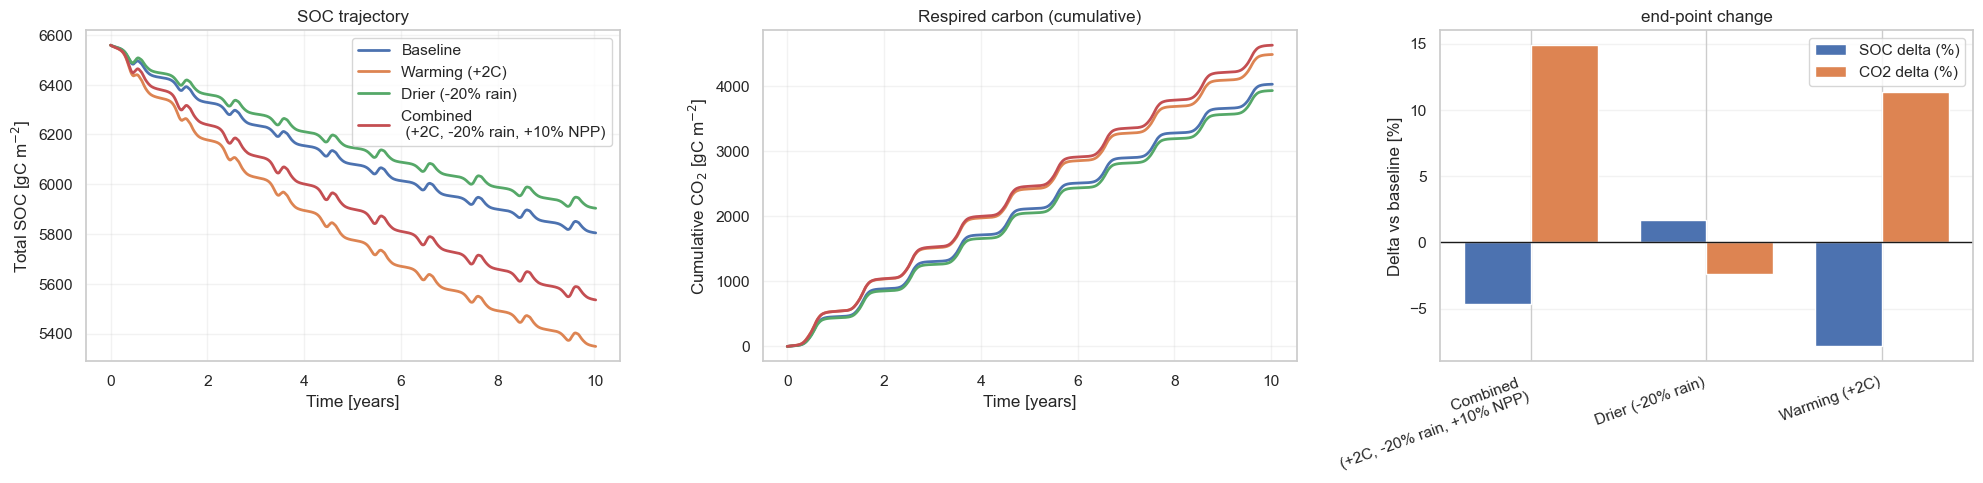

In [17]:
plot_scenario(results, summary_table)

> # **Student experiment: Try your own scenario!**
>
> You can design your own climate and microbial scenario by adjusting all five knobs below:
>
> - **dT**: Change the mean temperature (°C) to simulate warming or cooling.
> - **rain_mult**: Multiply rainfall by a factor (e.g., 0.8 for drier, 1.2 for wetter).
> - **npp_mult**: Multiply plant C input by a factor (e.g., 1.1 for more productivity).
> - **cue_mult**: Change microbial carbon use efficiency (CUE). Increasing this means microbes respire less per unit of carbon they take up (i.e., more efficient).
> - **bd_mult**: Change microbial turnover rate. Increasing this means microbes die faster, which can lead to more carbon being transferred to the MAOM pool (and less respired) if the MAOM formation pathway is efficient.
>
> ## **Try combinations!** 
> > For example, simulate a warmer, drier world with more efficient but shorter-lived microbes, or test the effect of increased plant inputs under different climate conditions. Observe how these changes affect soil carbon pools and $CO_2$ loss over time.

In [18]:
# example tohelp you build your own scenario
student_scenario_defs = {
    'Baseline': dict(dT=0.0, rain_mult=1.0, npp_mult=1.0, cue_mult=1.0, bd_mult=1.0),
    'efficient microbes (100%)': dict(dT=0, rain_mult=1.0, npp_mult=1.0, cue_mult=2.0, bd_mult=1.0),
    'fast necromass (100%)': dict(dT=0, rain_mult=1.0, npp_mult=1.0, cue_mult=1.0, bd_mult=2.0),
    'Combined \n (efficient but faster dying microbes)': dict(dT=0, rain_mult=1.0, npp_mult=1.0, cue_mult=2.0, bd_mult=2.0),
}


student_results, student_summary_table = run_all_scenario(student_scenario_defs)

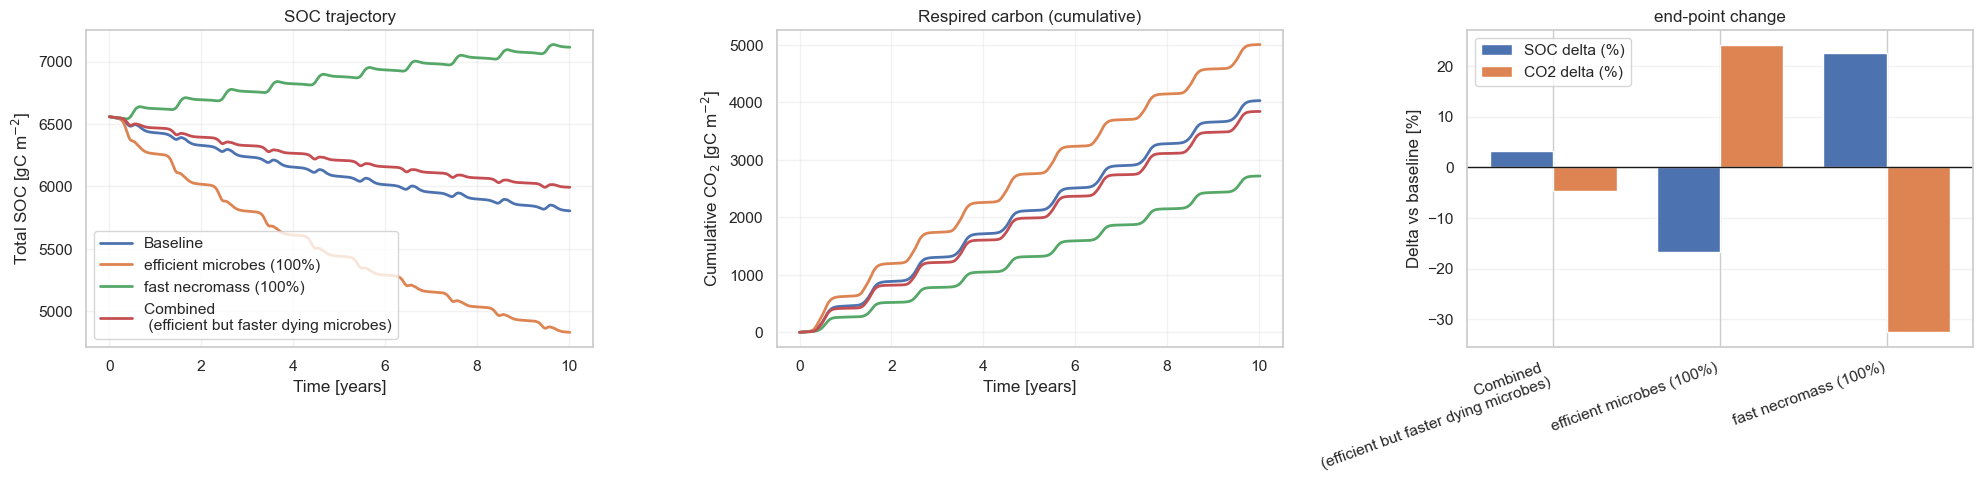

In [19]:
plot_scenario(student_results, student_summary_table)

### Wrap-up (3 minutes)

- Which scenario changed SOC the most?
- Did your prediction match the model?
- Why can warming and drying create competing effects?